# Claim 2a: the task vector's content varies measurably with demonstration input properties

Existence claim: do input manipulations change the task vector at all? Test by extracting the task vector from each manipulated ICL prompt and from the original prompt, then computing cosine similarity at each layer.

If similarity stays at ~1.0 across all conditions and all layers, the task vector is invariant to inputs and claim 2 is dead. If similarity drops for ablated conditions, the task vector responds to input properties — necessary precondition for it to mediate.

**Where is the 'task vector' extracted from?** The arrow position of the last demonstration in the ICL prompt — the standard Hendel/Todd extraction site. Per layer.

**What's the metric?** Cosine similarity between TV from manipulated prompt and TV from original prompt, computed per (prompt, condition, layer). Aggregated across prompts: mean + 95% CI.

In [1]:
import sys; sys.path.insert(0, '../..')
import torch, numpy as np, matplotlib.pyplot as plt, pickle, random, seaborn as sns
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
from math import sqrt
from transformer_lens import HookedTransformer
from configs import *
from utils import *
%matplotlib inline

sns.set_context('notebook')

model = HookedTransformer.from_pretrained(MODEL_NAME, device='cuda', dtype=torch.float16)
model.eval()
n_layers = model.cfg.n_layers

with open('../../configs/splits.pkl', 'rb') as f:
    all_splits = pickle.load(f)

rng = random.Random(42)

/home/cvllab/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-14 09:41:56.801471: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  3.00it/s]


Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer


## Build input pools and donor task mappings

In [2]:
W_E = model.W_E.detach()

input_pool_all = []
input_pool_all_tokids = []
for task_name, splits in all_splits.items():
    for pdata in splits['icl_prompts']:
        for inp, _ in pdata['demo_pairs']:
            input_pool_all.append(inp)
            toks = model.to_tokens(' ' + inp, prepend_bos=False)[0]
            input_pool_all_tokids.append(toks[0].item())

mean_input_embed = W_E[input_pool_all_tokids].mean(dim=0)

task_list = sorted(all_splits.keys())
donor_task = {}
for i, t in enumerate(task_list):
    donor_task[t] = task_list[(i + len(task_list) // 2) % len(task_list)]

task_input_tokids = {}
for t, splits in all_splits.items():
    tok_ids = []
    for pdata in splits['icl_prompts']:
        for inp, _ in pdata['demo_pairs']:
            toks = model.to_tokens(' ' + inp, prepend_bos=False)[0]
            tok_ids.append(toks[0].item())
    task_input_tokids[t] = tok_ids
task_mean_emb = {t: W_E[ids].mean(dim=0).float() for t, ids in task_input_tokids.items()}

related_donor_task = {}
for t in task_list:
    t_emb = task_mean_emb[t]
    best_sim, best_other = -float('inf'), None
    for other in task_list:
        if other == t: continue
        sim = torch.nn.functional.cosine_similarity(t_emb, task_mean_emb[other], dim=0).item()
        if sim > best_sim:
            best_sim, best_other = sim, other
    related_donor_task[t] = best_other

## Extract task vectors per condition per layer

For each prompt and each condition, run the ICL prompt through the model and cache the residual stream at the last demo's arrow position. Layer index runs over `resid_post` for each layer. Task vector at layer L = `cache['resid_post', L][0, arrow_pos]`.

In [3]:
CONDS = [
    'orig', 'shuffled', 
    # 'related_wrong_task_inputs', 
    'wrong_task_inputs',
    'random_from_input_pool', 'mean_embed', 'star', 'query_only']

RESID_FILTER = lambda name: 'resid_post' in name
tv_per_cond = {c: [] for c in CONDS}  # list of [n_layers, d_model] tensors per prompt
prompt_task = []

def make_embed_hook(positions, replacement_vec):
    def hook_fn(emb, hook):
        for p in positions:
            emb[:, p, :] = replacement_vec.to(emb.dtype)
        return emb
    return hook_fn

def get_query_arrow_position(model, prompt):
    """Return the position of the LAST arrow token in the prompt — i.e., the query arrow,
    which sits between the query input and where the answer would be generated."""
    # Find arrow token id. The standard separator is ' →' (space + arrow).
    arrow_tok = model.to_tokens(' →', prepend_bos=False)[0, 0].item()
    tokens = model.to_tokens(prompt, prepend_bos=True)[0]
    arrow_positions = (tokens == arrow_tok).nonzero().squeeze(-1).tolist()
    if not arrow_positions: return None
    return arrow_positions[-1]

def extract_tv(tokens, arrow_pos, hooks=None):
    """Return [n_layers, d_model] tensor of resid_post at arrow_pos."""
    with torch.no_grad():
        if hooks:
            with model.hooks(fwd_hooks=hooks):
                _, cache = model.run_with_cache(tokens, names_filter=RESID_FILTER)
        else:
            _, cache = model.run_with_cache(tokens, names_filter=RESID_FILTER)
    return torch.stack([cache['resid_post', L][0, arrow_pos].cpu().float() for L in range(n_layers)])

for task_name, splits in tqdm(list(all_splits.items())):
    donor_prompts         = all_splits[donor_task[task_name]]['icl_prompts']
    related_donor_prompts = all_splits[related_donor_task[task_name]]['icl_prompts']
    
    for p_idx, pdata in enumerate(splits['icl_prompts'][:10]):
        demos = pdata['demo_pairs']
        qi = pdata['query_input']
        ans = pdata.get('query_output')
        if ans is None: continue
        
        outputs = [o for _, o in demos]
        inputs  = [i for i, _ in demos]
        inputs_shuffled = inputs.copy(); rng.shuffle(inputs_shuffled)
        
        donor_pdata = donor_prompts[p_idx % len(donor_prompts)]
        inputs_wrong = [i for i, _ in donor_pdata['demo_pairs']]
        if len(inputs_wrong) < len(demos):
            inputs_wrong = (inputs_wrong * ((len(demos) // len(inputs_wrong)) + 1))[:len(demos)]
        inputs_wrong = inputs_wrong[:len(demos)]
        
        rel_pdata = related_donor_prompts[p_idx % len(related_donor_prompts)]
        inputs_related = [i for i, _ in rel_pdata['demo_pairs']]
        if len(inputs_related) < len(demos):
            inputs_related = (inputs_related * ((len(demos) // len(inputs_related)) + 1))[:len(demos)]
        inputs_related = inputs_related[:len(demos)]
        
        inputs_random = [rng.choice(input_pool_all) for _ in range(len(demos))]
        
        prompts = {
            'orig':       pdata['prompt'],
            'query_only': f"{pdata['query_input']} \u2192",
            'shuffled': build_icl_prompt(list(zip(inputs_shuffled, outputs)), qi),
            # 'related_wrong_task_inputs': build_icl_prompt(list(zip(inputs_related, outputs)), qi),
            'wrong_task_inputs':         build_icl_prompt(list(zip(inputs_wrong, outputs)), qi),
            'random_from_input_pool':    build_icl_prompt(list(zip(inputs_random, outputs)), qi),
            'star':     build_icl_prompt([('*', o) for o in outputs], qi),
        }
        tokens = {k: model.to_tokens(v, prepend_bos=True) for k, v in prompts.items()}
        
        # Find arrow position from each prompt independently (positions may differ)
        arrow_pos = {k: get_query_arrow_position(model, prompts[k]) for k in prompts}
        if any(a is None for a in arrow_pos.values()): continue
        
        for k in ['orig', 'shuffled', 'wrong_task_inputs',
                  'random_from_input_pool', 'star', 'query_only']:
            tv = extract_tv(tokens[k], arrow_pos[k])
            tv_per_cond[k].append(tv)
        
        # mean_embed: hook at hook_embed on the orig prompt
        per_demo_orig = find_per_demo_positions(model, prompts['orig'], demos)
        input_positions = [p for d in per_demo_orig for p in d.get('input_positions', [])]
        hook = [('hook_embed', make_embed_hook(input_positions, mean_input_embed))]
        tv = extract_tv(tokens['orig'], arrow_pos['orig'], hooks=hook)
        tv_per_cond['mean_embed'].append(tv)
        
        prompt_task.append(task_name)
        torch.cuda.empty_cache()

for c in CONDS:
    tv_per_cond[c] = torch.stack(tv_per_cond[c])  # [n_prompts, n_layers, d_model]
prompt_task = np.array(prompt_task)
total_n = len(prompt_task)
print(f'\nTotal prompts: {total_n}, n_layers: {n_layers}')
for c in CONDS:
    print(f'  {c:<28} shape={tuple(tv_per_cond[c].shape)}')

100%|██████████| 20/20 [01:00<00:00,  3.02s/it]


Total prompts: 200, n_layers: 28
  orig                         shape=(200, 28, 3072)
  shuffled                     shape=(200, 28, 3072)
  wrong_task_inputs            shape=(200, 28, 3072)
  random_from_input_pool       shape=(200, 28, 3072)
  mean_embed                   shape=(200, 28, 3072)
  star                         shape=(200, 28, 3072)
  query_only                   shape=(200, 28, 3072)


## Compute cosine similarity to TV(orig) per (prompt, condition, layer)

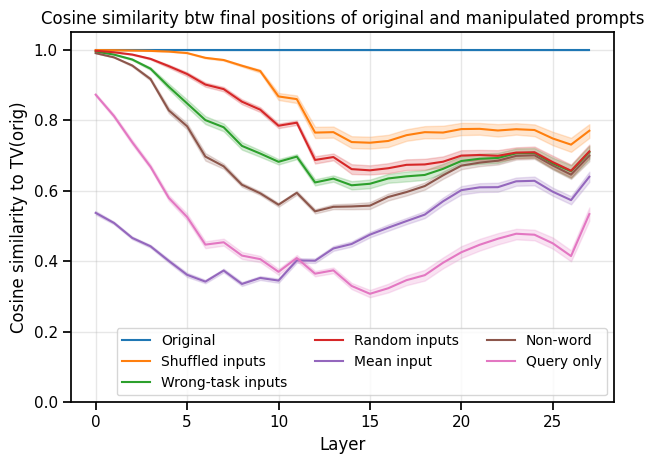

In [4]:
tv_orig = tv_per_cond['orig']  # [n, L, d]
cos_sim = {}  # condition -> [n_prompts, n_layers]
for c in CONDS:
    cos_sim[c] = torch.nn.functional.cosine_similarity(
        tv_per_cond[c], tv_orig, dim=-1
    ).numpy()  # [n, L]

# Aggregate plot
tick_map = {
    'orig': 'Original',
    'shuffled': 'Shuffled inputs',
    # 'related_wrong_task_inputs': 'Related wrong-task input',
    'wrong_task_inputs': 'Wrong-task inputs',
    'random_from_input_pool': 'Random inputs',
    'mean_embed': 'Mean input',
    'star': 'Non-word',
    'query_only': 'Query only',
}

rows = []
for c in CONDS:
    for p_idx in range(total_n):
        for L in range(n_layers):
            rows.append({'Condition': tick_map[c], 'Layer': L, 'CosineSim': cos_sim[c][p_idx, L]})
df_cos = pd.DataFrame(rows)
label_order = [tick_map[c] for c in CONDS]

fig, ax = plt.subplots(figsize=(6.4, 4.8))
sns.lineplot(data=df_cos, x='Layer', y='CosineSim', hue='Condition', hue_order=label_order,
             palette='tab10', errorbar=('ci', 95), ax=ax)
ax.set_ylabel('Cosine similarity to TV(orig)')
ax.set_xlabel('Layer')
ax.set_ylim(0, 1.05)
ax.set_title(f'Cosine similarity btw final positions of original and manipulated prompts')
ax.grid(True, alpha=0.3)
ax.legend(title='', loc='lower right', ncol=3, fontsize=10)
plt.tight_layout(); plt.show()

## Per-task panel

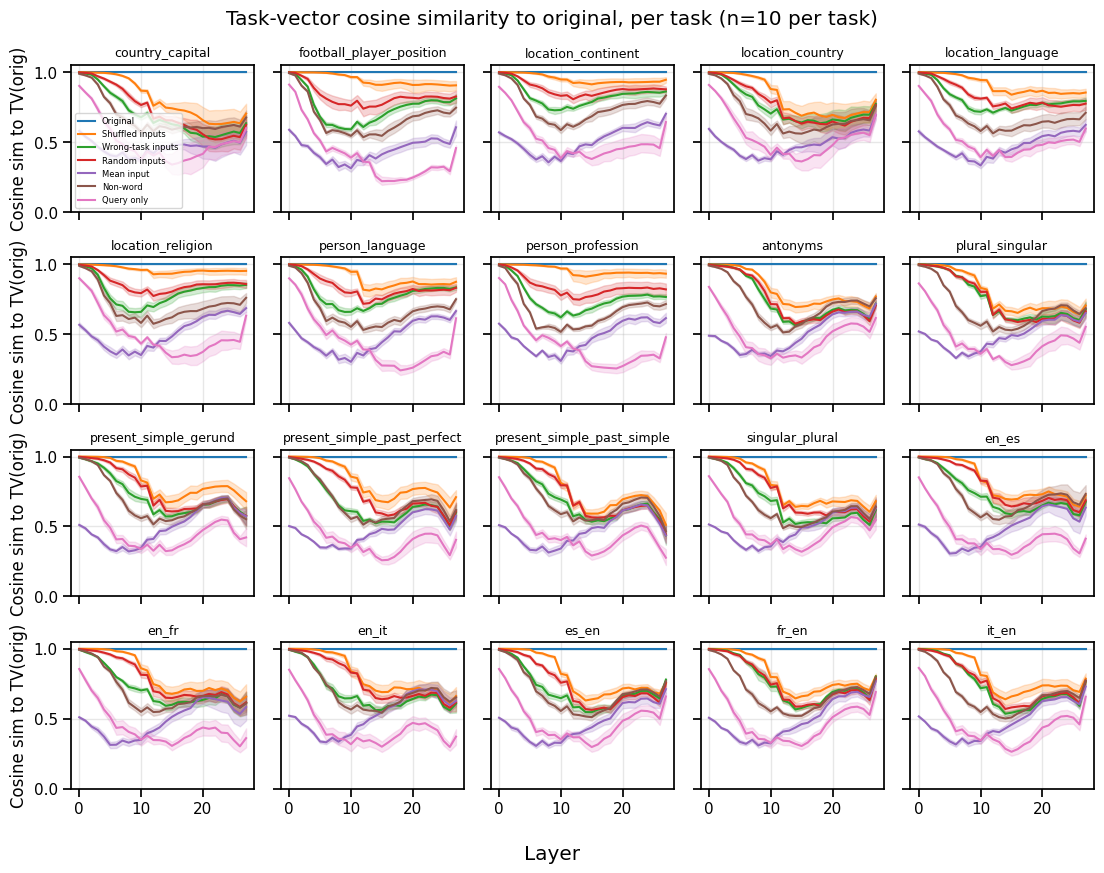

In [5]:
task_list_sorted = sorted(set(prompt_task))
n_cols = 5
n_rows = int(np.ceil(len(task_list_sorted) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.4*1.75, 2.2*n_rows),
                         sharey=True, sharex=True)
axes = axes.flatten()

for ax, t in zip(axes, task_list_sorted):
    mask = prompt_task == t
    sub_rows = []
    for c in CONDS:
        for p_idx in np.where(mask)[0]:
            for L in range(n_layers):
                sub_rows.append({'Condition': tick_map[c], 'Layer': L,
                                 'CosineSim': cos_sim[c][p_idx, L]})
    sub_df = pd.DataFrame(sub_rows)
    sns.lineplot(data=sub_df, x='Layer', y='CosineSim', hue='Condition', hue_order=label_order,
                 palette='tab10', errorbar=('ci', 95), ax=ax, legend=(ax is axes[0]))
    ax.set_title(t.split('/')[-1], fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('Cosine sim to TV(orig)' if ax in axes[::n_cols] else '')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

axes[0].legend(title='', loc='lower left', fontsize=6)
for ax in axes[len(task_list_sorted):]:
    ax.set_visible(False)

fig.supxlabel('Layer')
fig.suptitle(f'Task-vector cosine similarity to original, per task (n={mask.sum()} per task)')
plt.tight_layout(); plt.show()

## Task-direction projection

Cosine similarity to `orig` measures *direction* preservation only — it's scale-invariant. Two TVs with the same direction but different magnitudes have cosine = 1 but could produce very different downstream behavior because the patched residual's magnitude relative to surrounding content determines how strongly it drives the model's computation. To test magnitude-along-direction rather than direction alone, we project each TV onto a canonical task direction.

**Definition of task direction.** For each task T and each layer L, define `d_{T,L}` as the mean of `TV(orig)` across all prompts of task T at layer L, normalized to unit length: `d_{T,L} = mean_{p in T}(TV(orig, p, L)) / ||mean||`. This is the direction in residual-stream space that the model's task vector points in for task T at layer L.

**Projection metric.** For each prompt p of task T, each condition c, each layer L, compute the signed scalar projection: `proj(p, c, L) = TV(c, p, L) · d_{T,L}`. This scalar measures how far along the canonical task direction this TV extends. Positive and large means the TV strongly points in the task direction; near zero means orthogonal; negative means actively pointing *away* from the task direction.

**Normalization for interpretation.** Dividing each condition's projection by the mean projection of `orig` at the same layer gives a ratio: 1.0 means as much projection as the typical orig TV, 0.5 means half as much, 0 means no projection on the task direction, negative means anti-projection. This ratio is directly comparable across layers.

**Leave-one-out to avoid contamination.** Computing `d_{T,L}` from all orig prompts of task T and then evaluating orig's projection onto it gives a trivially high number. To avoid this, for each orig prompt we leave that prompt out when computing `d_{T,L}`. For other conditions, no leave-out is needed since the task direction is computed from orig only.

In [6]:
# Per (task, layer) canonical task direction from orig TVs, normalized to unit length.
# For each orig prompt, use leave-one-out so the prompt isn't in its own direction.
task_names = sorted(set(prompt_task))
task_to_idx = {t: np.where(prompt_task == t)[0] for t in task_names}

tv_orig = tv_per_cond['orig']  # [n, L, d]

proj = {c: np.zeros((total_n, n_layers), dtype=np.float32) for c in CONDS}

for t in task_names:
    idx = task_to_idx[t]
    if len(idx) < 2: continue
    orig_sum = tv_orig[idx].sum(dim=0)  # [L, d]
    for p_idx in idx:
        # Leave this prompt out of the direction for orig's own projection
        d_loo = (orig_sum - tv_orig[p_idx]) / (len(idx) - 1)  # [L, d]
        d_loo_norm = d_loo / d_loo.norm(dim=-1, keepdim=True).clamp(min=1e-9)
        
        proj['orig'][p_idx] = (tv_orig[p_idx] * d_loo_norm).sum(dim=-1).numpy()
    
    # For non-orig conditions, use the full-orig direction (no leave-out needed)
    d_full = orig_sum / len(idx)
    d_full_norm = d_full / d_full.norm(dim=-1, keepdim=True).clamp(min=1e-9)
    for c in CONDS:
        if c == 'orig': continue
        for p_idx in idx:
            proj[c][p_idx] = (tv_per_cond[c][p_idx] * d_full_norm).sum(dim=-1).numpy()

# Normalize each condition's projection by the mean orig projection at each layer
orig_mean_per_layer = proj['orig'].mean(axis=0)  # [L]
proj_ratio = {c: proj[c] / np.maximum(orig_mean_per_layer, 1e-9) for c in CONDS}

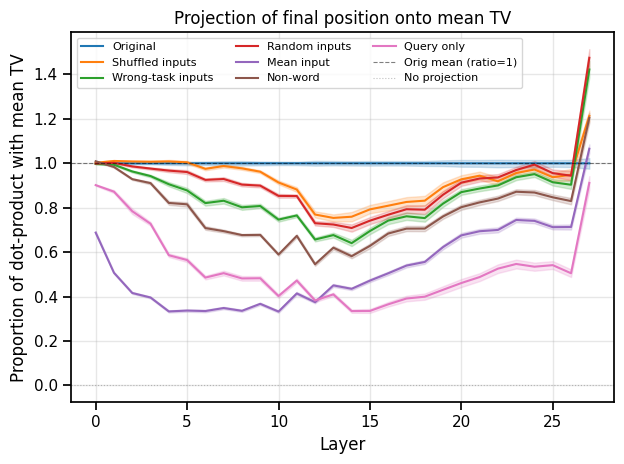

: 

In [17]:
rows = []
for c in CONDS:
    for p_idx in range(total_n):
        for L in range(n_layers):
            rows.append({'Condition': tick_map[c], 'Layer': L, 'ProjectionRatio': proj_ratio[c][p_idx, L]})
df_proj = pd.DataFrame(rows)
label_order = [tick_map[c] for c in CONDS]

fig, ax = plt.subplots(figsize=(6.4, 4.8))
sns.lineplot(data=df_proj, x='Layer', y='ProjectionRatio', hue='Condition', hue_order=label_order,
             palette='tab10', errorbar=('ci', 95), ax=ax)
ax.axhline(1.0, color='black', lw=0.8, ls='--', alpha=0.5, label='Orig mean (ratio=1)')
ax.axhline(0.0, color='gray', lw=0.8, ls=':',  alpha=0.5, label='No projection')
ax.set_ylabel('Proportion of dot-product with mean TV')
ax.set_xlabel('Layer')
ax.set_title(f'Projection of final position onto mean TV')
ax.grid(True, alpha=0.3)
ax.legend(title='', loc='upper left', ncol=3, fontsize=8)
plt.tight_layout(); plt.show()